In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import Basic_functions as bf
from scipy.sparse import hstack, vstack, csr_array, save_npz, load_npz

In [2]:
import sklearn.utils as sku
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, roc_curve, log_loss, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, r2_score
import lightgbm as lgbm
from lightgbm import early_stopping
import optuna as opt

In [2]:
raw = open("Speeches\Aaja_Chemnitz'_tale_ved_den_udvidede_spørgetime_med_statsministeren.txt", "r", encoding="utf-8").read()
text, header = bf.extract_header(raw)

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\jonas\AppData\Local\Temp\ipykernel_8536\254240665.py:1: SyntaxWarning: invalid escape sequence '\A'
  raw = open("Speeches\Aaja_Chemnitz'_tale_ved_den_udvidede_spørgetime_med_statsministeren.txt", "r", encoding="utf-8").read()


In [3]:
chars = "abcdefghijklmnopqrstuvwxyzæøå "
bigons = []
trigons = []
for i in range(len(chars)):
    for j in range(len(chars)):
        bigons.append(chars[i] + chars[j])
for i in range(len(chars)):
    for j in range(len(chars)):
        for k in range(len(chars)):
            trigons.append(chars[i] + chars[j] + chars[k])

In [27]:
raw = open("Speeches/Zenia_Stampes_grundlovstale.txt", "r", encoding="utf-8").read()
text, header = bf.extract_header(raw)
text = text.strip().lower().replace("\n", " ")
header_lines = header.splitlines()

In [3]:
#np.savetxt("words_by_speech.csv", words, delimiter=",", fmt="%s")
#np.savetxt("counts_by_speech.csv", counts, delimiter=",", fmt="%d")
with open("txt_files/words_by_speech.txt", "w", encoding="utf-8") as f:
    for i in range(len(words)):
        for j in range(len(words[i])):
            f.write(words[i][j])
            f.write(", ")
        f.write("\n")
with open("txt_files/counts_by_speech.txt", "w") as f:
    for i in range(len(counts)):
        for j in range(len(counts[i])):
            f.write(str(counts[i][j]))
            f.write(", ")
        f.write("\n")

NameError: name 'words' is not defined

In [38]:
words = np.genfromtxt("txt_files/words_ranked_years.txt", delimiter=", ", dtype=str)

In [4]:
empty_char = [" "]
trigons_filtered = np.genfromtxt("txt_files/trigons_filtered.txt", delimiter="\n", dtype=str)
data_speech, labels_speech = bf.read_files("Speeches", empty_char, sparse=True)

In [ ]:
#np.savetxt("Data_files/labels_speech.txt", labels_speech, delimiter=", ", fmt="%s")

In [71]:
data_article_06, labels_article_06 = bf.read_files("../ML2026_Files/Articles_06", trigons, sparse=True)
save_npz("Data_files/data_articles_06.npz", data_article_06)
np.savetxt("Data_files/labels_articles_06.txt", labels_article_06, delimiter="; ", fmt="%s")

In [ ]:
#save_npz("Data_files/data_speech.npz", data_speech)
#np.savetxt("Data_files/labels_speech.txt", labels_speech, delimiter=", ", fmt="%s")

In [3]:
data_articles_dict = {}
labels_articles_dict = {}
for i in range(5, 14):
    if i < 10:
        data_articles_dict[i] = load_npz(f"Data_files/data_articles_0{i}.npz")
        labels_articles_dict[i] = np.genfromtxt(f"Data_files/labels_articles_0{i}.txt", delimiter="; ", dtype=str)
    else:
        data_articles_dict[i] = load_npz(f"Data_files/data_articles_{i}.npz")
        labels_articles_dict[i] = np.genfromtxt(f"Data_files/labels_articles_{i}.txt", delimiter="; ", dtype=str)

In [4]:
data_articles = vstack([data_articles_dict[i] for i in range(5, 14)])
labels_articles = np.concatenate([labels_articles_dict[i] for i in range(5, 14)])
data_articles = hstack([labels_articles[:,4].astype(float).reshape(-1, 1), data_articles], format="csr")
sort_idx = np.genfromtxt("txt_files/regression_sort_idx.txt", delimiter="\n", dtype=int)
mask = labels_articles[:, 0].astype(float) < 2026.5
data_articles = data_articles[:, sort_idx][mask]
labels_articles = labels_articles[mask]

In [5]:
#Free the memory used by the dicts
data_articles_dict = None
labels_articles_dict = None

In [3]:
data_speech = load_npz("Data_files/data_speech.npz")
data_speech_nltk = load_npz("tfidf_NLTK_Speeches.npz")
labels_speech = np.genfromtxt("Data_files/labels_speech.txt", delimiter="; ", dtype=str)
data_speech = hstack([labels_speech[:,4].astype(float).reshape(-1, 1), data_speech], format="csr")

In [ ]:
labels_nltk = np.genfromtxt('Data_files/labels_nltk.txt', delimiter=';', dtype=str, skip_header=1, encoding='utf-8')
data_nltk = load_npz("Data_files/data_nltk.npz")
data_nltk = hstack([labels_nltk[:,0].astype(float).reshape(-1, 1), data_nltk], format="csr")
data_nltk = data_nltk[labels_nltk[:, 2].astype(int) == 1, :]
data_comb, labels_comb = sku.shuffle(data_nltk, labels_nltk[:,3], random_state=5466542)

In [25]:
labels_speeches = labels_nltk[:, 2].astype(int)

In [9]:
data_articles_shuff, labels_articles_shuff = sku.shuffle(data_articles, labels_articles, random_state=42)
labels_articles_shuff = labels_articles_shuff[:, 0].astype(float)
data_comb = data_articles_shuff
labels_comb = labels_articles_shuff
#data_comb = vstack([data_speech, data_articles_shuff[:len(labels_speech)*100]])
#labels_comb = np.concatenate([labels_speech, labels_articles_shuff[:len(labels_speech)*100]])
#labels_comb = np.concatenate([np.ones((labels_speech.shape[0])), np.zeros((labels_speech.shape[0])*100)])

In [10]:
labels_articles_shuff

array([2014.01369863, 2014.0630137 , 2012.05205479, ..., 2011.19680365,
       2012.25547945, 2011.64086758], shape=(417819,))

In [11]:
#Free the memory used by the unused articles data
data_articles = None
labels_articles = None
#data_articles_shuff = None
#labels_articles_shuff = None

In [17]:
#data_comb_shuff, labels_comb_shuff = sku.shuffle(data_comb, labels_comb, random_state=5466542)
#sort_idx = np.genfromtxt("txt_files/speeches_sort_idx.txt", delimiter="\n", dtype=int)
#data_comb_shuff = data_comb_shuff[:, sort_idx][:, :1000]

In [5]:
data_comb, labels_comb = sku.shuffle(data_speech, labels_speech[:,0].astype(float), random_state=5466542)
sort_idx = np.genfromtxt("txt_files/sermons_sort_idx.txt", delimiter="\n", dtype=int)
data_comb = data_comb[:, sort_idx][:, :27001]

In [26]:
topic_names = []
topic_counts = []
for i in range(len(labels_comb)):
    if labels_comb[i] not in topic_names:
        topic_names.append(labels_comb[i])
        topic_counts.append(1)
    else:
        idx = topic_names.index(labels_comb[i])
        topic_counts[idx] += 1

topic_names = np.array(topic_names)
topic_counts = np.array(topic_counts)

In [27]:
sorted_indices = np.argsort(topic_counts)[::-1]
topic_names = topic_names[sorted_indices]
topic_counts = topic_counts[sorted_indices]

mask = topic_counts > 11750
topic_names_masked = np.array(topic_names)[mask]
topic_counts_masked = np.array(topic_counts)[mask]

#plt.figure(figsize=(10, 6))
#plt.bar(topic_names_masked, topic_counts_masked)
#plt.xticks(rotation=45)

In [28]:
len(topic_counts_masked)

10

In [29]:
topic_names_masked

array(['Danmark', 'Internationalt', 'Politik', 'Kultur', 'Sport',
       'Fodbold', 'Økonomi', 'Forbrug', 'Film og tv', 'Cykling'],
      dtype='<U153')

In [30]:
#Topics = ["Internationalt", "Danmark", "Politik", "Sport", "Forbrug", "Kultur", "Fodbold", "Økonomi", "Film og tv", "Sundhed"]
topic_labels = []
kept_rows = []
for i in range(len(labels_comb)):
    for j, topic in enumerate(topic_names_masked):
        if labels_comb[i] == topic:
            topic_labels.append(j)
            kept_rows.append(i)
topic_data = data_comb[kept_rows]

In [31]:
topic_data

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 21240137 stored elements and shape (434564, 64479)>

In [46]:
topic_data_reduced = topic_data[:150000, :]
topic_labels_reduced = topic_labels[:150000]

In [47]:
topic_data_reduced

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7339828 stored elements and shape (150000, 64479)>

In [48]:
data_comb_red = data_comb[:, :3000] 
data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(topic_data_reduced, topic_labels_reduced, val_size=0.20, test_size=0.00)

In [49]:
params_regress = {
    "objective": "regression",
    "boosting_type": "gbdt",
    "num_leaves": 200,
    "min_data_in_leaf": 10,
    "learning_rate": 0.02,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

params_class = {
    "objective": "multiclass",
    "num_class": 10,
    "boosting_type": "gbdt",
    "num_leaves": 100,
    "min_data_in_leaf": 5,
    "learning_rate": 0.02,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

params_binary = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "num_leaves": 100,
    "min_data_in_leaf": 5,
    "learning_rate": 0.02,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

In [17]:
lgb_train = lgbm.Dataset(data_train, label=data_train_labels)
lgb_val = lgbm.Dataset(data_val, label=data_val_labels, reference=lgb_train)
def objective(trial):
    params = {
        'boosting_type': 'gbdt', 
        'scale_pos_weight': 100,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3),     
        'num_leaves': trial.suggest_int('num_leaves', 5, 1000),         
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 1000),  
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'objective': 'binary',   # The outcome is binary classification
        'verbosity': -1,          # Level of output. Can be set to -1 to suppress the output
        'feature_pre_filter': False, # Disable feature pre-filtering to ensure all features are considered
    }
    
    gbm = lgbm.train(params, lgb_train, num_boost_round=1000, valid_sets=[lgb_val], callbacks=[lgbm.early_stopping(50)])
    loss = gbm.best_score['valid_0']['binary_logloss']
    return loss

In [19]:
opt.logging.set_verbosity(opt.logging.WARNING)
study = opt.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
print("Best trial:", study.best_trial)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[172]	valid_0's binary_logloss: 0.0155709
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[45]	valid_0's binary_logloss: 0.017615
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[88]	valid_0's binary_logloss: 0.0149838
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.0417598
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[106]	valid_0's binary_logloss: 0.0153631
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[58]	valid_0's binary_logloss: 0.0191992
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[64]	valid_0's binary_logloss: 0.0150967
Training until validation scores don't im

In [23]:
params_sermons_nltk = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "num_leaves": 450,
    "min_data_in_leaf": 300,
    "learning_rate": 0.2,
    "feature_fraction": 0.65,
    "bagging_fraction": 0.5,
    "bagging_freq": 3,
    "verbose": -1
}

params_speeches_nltk = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "scale_pos_weight": 100,
    "num_leaves": 900,
    "min_data_in_leaf": 900,
    "learning_rate": 0.25,
    "feature_fraction": 0.7,
    "bagging_fraction": 0.6,
    "bagging_freq": 7,
    "verbose": -1
}

In [37]:
params_sermons = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "num_leaves": 350,
    "min_data_in_leaf": 350,
    "learning_rate": 0.1,
    "feature_fraction": 0.75,
    "bagging_fraction": 0.6,
    "bagging_freq": 8,
    "verbose": -1
}
params_speeches = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "scale_pos_weight": 100.0,
    "num_leaves": 250,
    "min_data_in_leaf": 375,
    "learning_rate": 0.02,
    "feature_fraction": 0.95,
    "bagging_fraction": 0.65,
    "bagging_freq": 5,
    "verbose": -1
}
params_multiclass = {
    "objective": "multiclass",
    "num_class": 10,
    "boosting_type": "gbdt",
    "num_leaves": 100,
    "min_data_in_leaf": 300,
    "learning_rate": 0.03,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 2,
    "device": "cpu",
    "verbose": -1
}
params_regress = {
    "objective": "regression",
    "boosting_type": "gbdt",
    "num_leaves": 275,
    "min_data_in_leaf": 25,
    "learning_rate": 0.03,
    "feature_fraction": 0.75,
    "bagging_fraction": 0.65,
    "bagging_freq": 3,
    "verbose": -1
}

In [51]:
lgb_train = lgbm.Dataset(data_train, label=data_train_labels)
lgb_val = lgbm.Dataset(data_val, label=data_val_labels, reference=lgb_train)
model_class = lgbm.train(params_class, lgb_train, valid_sets=[lgb_val], valid_names=["val"], num_boost_round=3000, callbacks=[early_stopping(stopping_rounds=200)])

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[590]	val's multi_logloss: 0.864423


In [54]:
idx = np.argsort(model_class.feature_importance(importance_type="gain"))[::-1]
np.savetxt("txt_files/multiclass_nltk_sort_idx.txt", idx, delimiter="\n", fmt="%d")

In [53]:
predictions = model_class.predict(data_test, num_iteration=model_class.best_iteration)
log_loss_score = log_loss(data_test_labels, predictions)
log_loss_score

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [17]:
predictions = model_class.predict(data_test, num_iteration=model_class.best_iteration)
log_loss_score = mean_squared_error(data_test_labels, predictions)
r2_score_value = r2_score(data_test_labels, predictions)
log_loss_score, r2_score_value

(4.41581958595493, 0.3618563779480397)

In [35]:
tpr, fpr, tnr, fnr = 0, 0, 0, 0
for i, pred in enumerate(predictions):
    if pred > 0.5:
        if data_test_labels[i] == 1:
            tpr += 1
        else:
            fpr += 1
    else:
        if data_test_labels[i] == 0:
            tnr += 1
        else:
            fnr += 1
print("True Positive Rate:", tpr / (tpr + fnr))
print("False Positive Rate:", fpr / (fpr + tnr))
print("True Negative Rate:", tnr / (tnr + fpr))
print("False Negative Rate:", fnr / (fnr + tpr))
print("Accuracy:", (tpr + tnr) / len(data_test_labels))

True Positive Rate: 0.9999226165910029
False Positive Rate: 0.29914529914529914
True Negative Rate: 0.7008547008547008
False Negative Rate: 7.738340899711101e-05
Accuracy: 0.9981283011127634


In [ ]:
tpr, fpr, tnr, fnr = 0, 0, 0, 0
for i, pred in enumerate(predictions):
    arg = np.argmax(pred)
    if arg == data_test_labels[i]:
        tpr += 1
    else:
        fpr += 1
#print("True Positive Rate:", tpr / (tpr + fnr))
#print("False Positive Rate:", fpr / (fpr + tnr))
#print("True Negative Rate:", tnr / (tnr + fpr))
#print("False Negative Rate:", fnr / (fnr + tpr))
print("Accuracy:", (tpr + tnr) / len(data_test_labels))

468

In [42]:
data_test_labels_mirror = np.array([1 if label == 0 else 0 for label in data_test_labels])

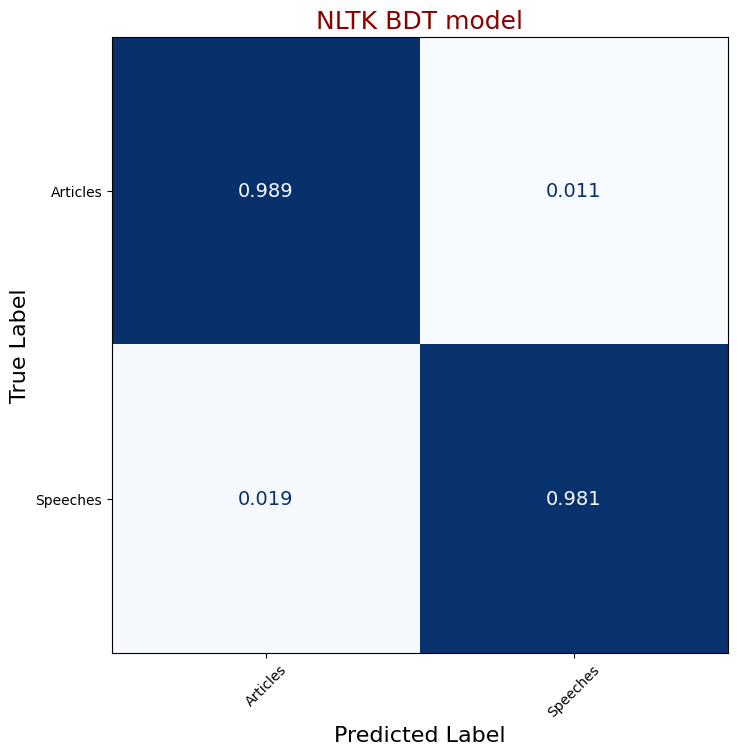

In [50]:
cm = confusion_matrix(data_test_labels_mirror, predictions < 0.9999, normalize='true')
classes = ["Articles", "Speeches"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax = ax, xticks_rotation=45, cmap=plt.cm.Blues, colorbar=False, values_format=".3f")
for t in disp.text_.ravel():
    t.set_fontsize(14)
plt.title("NLTK BDT model", fontsize=18, color="darkred")
plt.xlabel("Predicted Label", fontsize=16)
plt.ylabel("True Label", fontsize=16)
plt.savefig("confusion_matrix_class.png", dpi=300)
plt.show()

In [27]:
x.shape

(41781,)

In [33]:
time_sort = data_test_labels.argsort()
x = data_test_labels[time_sort]
y = predictions[time_sort]
y_mean = np.zeros(42)
x_mean = np.zeros(42)
for i, y_i in enumerate(y):
    y_mean[i//1000] += y_i
    x_mean[i//1000] += x[i]
y_mean = y_mean / 1000
x_mean = x_mean / 1000
x_mean[-1] = x_mean[-1]*1000/781
y_mean[-1] = y_mean[-1]*1000/781

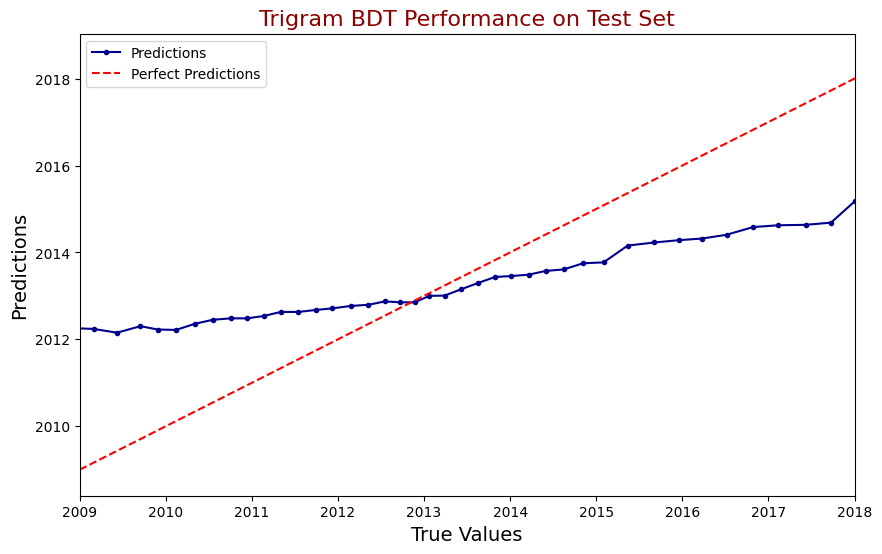

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(x_mean, y_mean, '.-', color='darkblue', label='Predictions')
plt.plot([np.min(x_mean), np.max(x_mean)], [np.min(x_mean), np.max(x_mean)], 'r--', label='Perfect Predictions')  # Add a reference line for perfect predictions
plt.xlabel('True Values', fontsize=14)
plt.ylabel('Predictions', fontsize=14)
plt.title('Trigram BDT Performance on Test Set', fontsize=16, color='darkred')
plt.legend()
plt.xlim(2009, 2018)
plt.savefig("Smaller_regression.png", dpi=300, bbox_inches='tight')
plt.show()

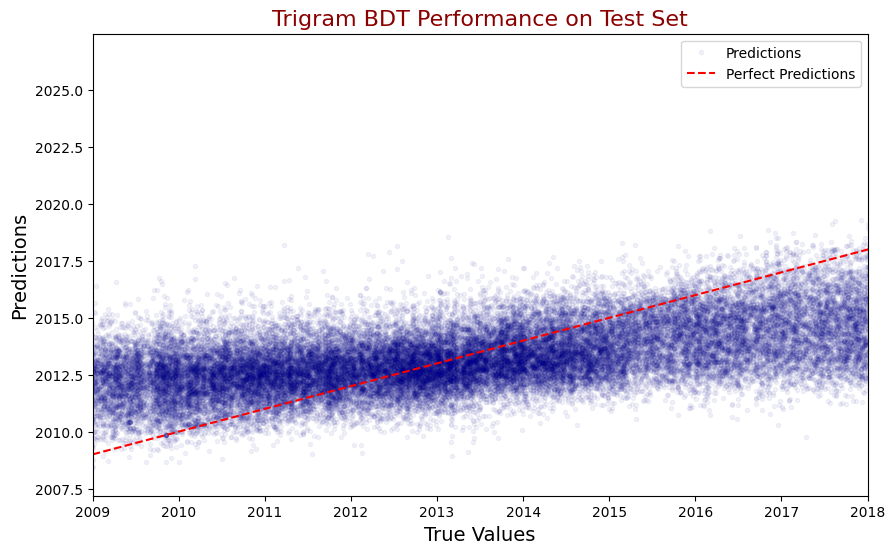

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(data_test_labels, predictions, '.', color='darkblue', alpha=0.05, label='Predictions')
plt.plot([np.min(data_test_labels), np.max(data_test_labels)], [np.min(data_test_labels), np.max(data_test_labels)], 'r--', label='Perfect Predictions')  # Add a reference line for perfect predictions
plt.xlabel('True Values', fontsize=14)
plt.ylabel('Predictions', fontsize=14)
plt.title('Trigram BDT Performance on Test Set', fontsize=16, color='darkred')
plt.legend()
plt.xlim(2009, 2018)
#plt.savefig("Model_Performance.png", dpi=300, bbox_inches='tight')
plt.show()

In [116]:
gain = model_binary.feature_importance(importance_type="gain", iteration=model_binary.best_iteration)
gain_idx = np.argsort(gain)[::-1]
data_sort = data_comb[:, gain_idx]

In [33]:
def calculate_tpr_fpr_auc(y_true, y_scores):
    fpr = np.linspace(0, 1, 50000)
    tpr = np.zeros_like(fpr)
    for i in range(10):
        fpr_part, tpr_part, _ = roc_curve(y_true, y_scores[:, i], pos_label=i)
        old_idx = 0
        for j, fpr_subpart in enumerate(fpr_part):
            idx = np.searchsorted(fpr, fpr_subpart)
            tpr[old_idx:idx] += tpr_part[j]
            old_idx = idx
    auc = roc_auc_score(y_true, y_scores, multi_class="ovr", average="macro")
    tpr /= 10
    tpr[-1] = 1
    return tpr, fpr, auc

In [32]:
Used_features = [10, 50, 150, 300, 500, 1500, 2500, 5000, 10000, 15000, 27000]
err_comb = []
for features in Used_features:
    data_train_red = data_comb[:, :features]
    data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(data_train_red, labels_comb, val_size=0.20, test_size=0.00)
    lgb_train = lgbm.Dataset(data_train, label=data_train_labels)
    lgb_val = lgbm.Dataset(data_val, label=data_val_labels, reference=lgb_train)
    model_regress_red = lgbm.train(params_regress, lgb_train, valid_sets=[lgb_val], valid_names=["val"], num_boost_round=3000, callbacks=[early_stopping(stopping_rounds=100)])
    error = model_regress_red.best_score
    err_comb.append(error["val"]["l2"])

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[165]	val's l2: 18.8758
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[298]	val's l2: 13.5472
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[724]	val's l2: 12.7623
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1010]	val's l2: 12.2223
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[845]	val's l2: 11.6988
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1018]	val's l2: 11.1781
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1243]	val's l2: 11.0376
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1253]	val's l2: 10.9563
Training until validation sc

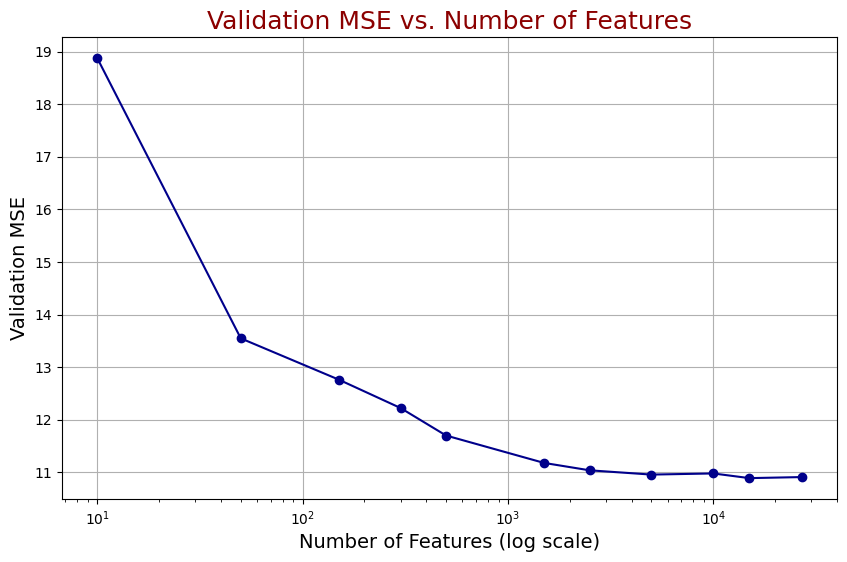

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(Used_features, err_comb, 'o-', color="darkblue")
plt.xscale('log')
plt.xlabel('Number of Features (log scale)', fontsize=14)
plt.ylabel('Validation MSE', fontsize=14)
plt.title('Validation MSE vs. Number of Features', fontsize=18, color="darkred")
plt.grid(True)
plt.savefig("validation_mse_vs_features.png", dpi=300)
plt.show()

In [88]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

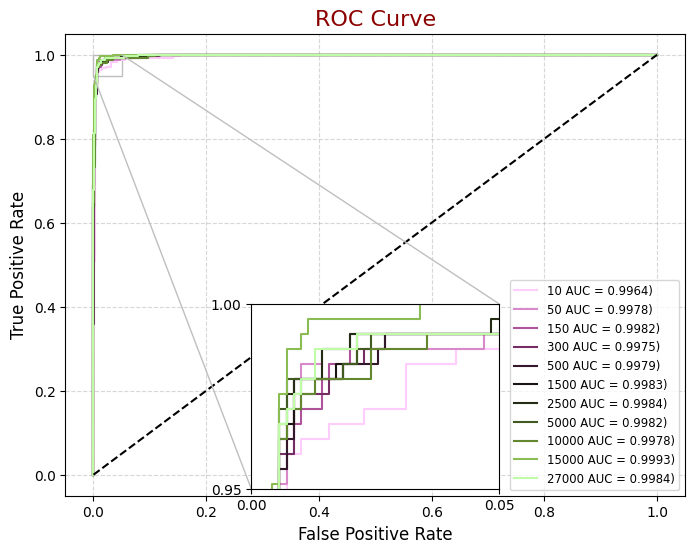

In [92]:
fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.cm.vanimo(np.linspace(0, 1, len(Used_features)))

axins = inset_axes(ax, width="40%", height="40%", loc="lower center")
for i in range(len(Used_features)):
    ax.plot(fpr_comb[i], tpr_comb[i], label=f"{Used_features[i]} AUC = {auc_comb[i]:.4f})", color=cmap[i])
    axins.plot(fpr_comb[i], tpr_comb[i], label=f"{Used_features[i]} AUC = {auc_comb[i]:.4f})", color=cmap[i])
axins.set_xlim(0.00, 0.05)
axins.set_ylim(0.95, 1.00)
axins.set_xticks(np.arange(0.00, 0.06, 0.05))
axins.set_yticks(np.arange(0.95, 1.01, 0.05))
axins.grid(True, linestyle="--", alpha=0.5)
mark_inset(ax, axins, loc1=1, loc2=3, fc="none", ec="0.75")


ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve", fontsize=16, color="darkred")
ax.legend(loc="lower right", fontsize="small")
ax.grid(True, linestyle="--", alpha=0.5)    
plt.savefig("ROC_Curve_Sermons.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
def data_time_split(data, labels, split_year):
    data_early = data[labels < split_year]
    labels_early = labels[labels < split_year]
    data_late = data[labels >= split_year]
    labels_late = labels[labels >= split_year]
    return data_early, labels_early, data_late, labels_late

In [7]:
data_train, labels_train, data_val, labels_val, data_test, labels_test = bf.train_val_test_split(data_comb, labels_comb, val_size=0.20, test_size=0.10)
data_train_early, labels_train_early, data_train_temp, labels_train_temp = data_time_split(data_train, labels_train, 1800)
data_train_middle, labels_train_middle, data_train_late, labels_train_late = data_time_split(data_train_temp, labels_train_temp, 2000)
data_val_early, labels_val_early, data_val_temp, labels_val_temp = data_time_split(data_val, labels_val, 1800)
data_val_middle, labels_val_middle, data_val_late, labels_val_late = data_time_split(data_val_temp, labels_val_temp, 2000)

In [20]:
params_class = {
    "objective": "multiclass",
    "num_class": 3,
    "boosting_type": "gbdt",
    "num_leaves": 250,
    "min_data_in_leaf": 20,
    "learning_rate": 0.02,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

params_regression = {
    "objective": "regression",
    "boosting_type": "gbdt",
    "num_leaves": 250,
    "min_data_in_leaf": 5,
    "learning_rate": 0.02,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

In [10]:
labels_train_class = labels_train
labels_train_class[labels_train_class < 1800] = 0
labels_train_class[(labels_train_class >= 1800) & (labels_train_class < 2000)] = 1
labels_train_class[labels_train_class >= 2000] = 2
labels_val_class = labels_val
labels_val_class[labels_val_class < 1800] = 0
labels_val_class[(labels_val_class >= 1800) & (labels_val_class < 2000)] = 1
labels_val_class[labels_val_class >= 2000] = 2

In [15]:
lgb_train = lgbm.Dataset(data_train, label=labels_train_class)
lgb_val = lgbm.Dataset(data_val, label=labels_val_class, reference=lgb_train)
model_multiclass = lgbm.train(params_class, lgb_train, valid_sets=[lgb_val], valid_names=["val"], num_boost_round=3000, callbacks=[early_stopping(stopping_rounds=200)])

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[139]	val's multi_logloss: 0.128483


In [19]:
data_train_early

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 66925 stored elements and shape (35, 27000)>

In [24]:
lgb_train_reg1 = lgbm.Dataset(data_train_early, label=labels_train_early)
lgb_val_reg1 = lgbm.Dataset(data_val_early, label=labels_val_early, reference=lgb_train_reg1)
model_regression_early = lgbm.train(params_regression, lgb_train_reg1, valid_sets=[lgb_val_reg1], valid_names=["val"], num_boost_round=30000, callbacks=[early_stopping(stopping_rounds=200)])

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[10485]	val's l2: 252300


In [22]:
lgb_train_reg2 = lgbm.Dataset(data_train_middle, label=labels_train_middle)
lgb_val_reg2 = lgbm.Dataset(data_val_middle, label=labels_val_middle, reference=lgb_train_reg2)
model_regression_middle = lgbm.train(params_regression, lgb_train_reg2, valid_sets=[lgb_val_reg2], valid_names=["val"], num_boost_round=3000, callbacks=[early_stopping(stopping_rounds=200)])

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[382]	val's l2: 222.984


In [23]:
lgb_train_reg3 = lgbm.Dataset(data_train_late, label=labels_train_late)
lgb_val_reg3 = lgbm.Dataset(data_val_late, label=labels_val_late, reference=lgb_train_reg3)
model_regression_late = lgbm.train(params_regression, lgb_train_reg3, valid_sets=[lgb_val_reg3], valid_names=["val"], num_boost_round=3000, callbacks=[early_stopping(stopping_rounds=200)])

Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[2996]	val's l2: 20.4307


In [41]:
test_pred_multiclass = model_multiclass.predict(data_test, num_iteration=model_multiclass.best_iteration)

In [42]:
test_classified = np.argmax(test_pred_multiclass, axis=1)
test_early = data_test[test_classified == 0]
test_middle = data_test[test_classified == 1]
test_late = data_test[test_classified == 2]
labels_test_early = labels_test[test_classified == 0]
labels_test_middle = labels_test[test_classified == 1]
labels_test_late = labels_test[test_classified == 2]

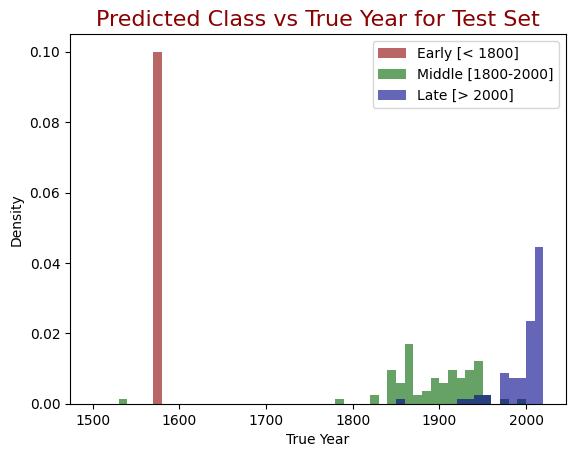

In [47]:
plt.hist(labels_test[test_classified == 0], bins=np.arange(1500, 2030, 10), label="Early [< 1800]", color="darkred", alpha=0.6, density=True)
plt.hist(labels_test[test_classified == 1], bins=np.arange(1500, 2030, 10), label="Middle [1800-2000]", color="darkgreen", alpha=0.6, density=True)
plt.hist(labels_test[test_classified == 2], bins=np.arange(1500, 2030, 10), label="Late [> 2000]", color="darkblue", alpha=0.6, density=True)
plt.xlabel("True Year")
plt.ylabel("Density")
plt.title("Predicted Class vs True Year for Test Set", fontsize=16, color="darkred")
plt.legend()
plt.show()

In [44]:
test_pred_early = model_regression_early.predict(test_early, num_iteration=model_regression_early.best_iteration)
test_pred_middle = model_regression_middle.predict(test_middle, num_iteration=model_regression_middle.best_iteration)
test_pred_late = model_regression_late.predict(test_late, num_iteration=model_regression_late.best_iteration)
test_pred_combined = np.concatenate((test_pred_early, test_pred_middle, test_pred_late))
labels_test_combined = np.concatenate((labels_test_early, labels_test_middle, labels_test_late))

In [41]:
labels_test_late.min()

np.float64(1688.0)

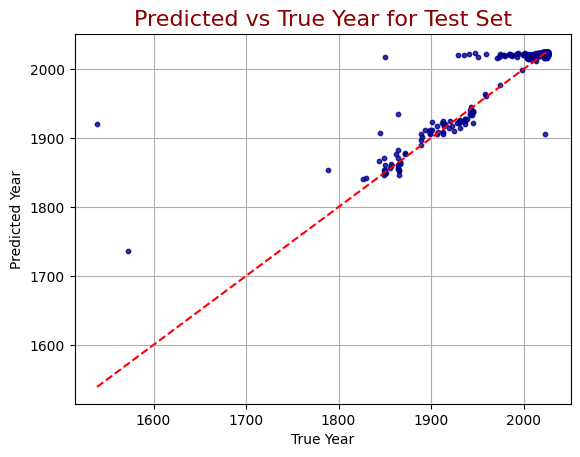

In [48]:
plt.scatter(labels_test_combined, test_pred_combined, alpha=0.8, s=10, color="darkblue", zorder=2)
plt.plot([labels_test_combined.min(), labels_test_combined.max()], [labels_test_combined.min(), labels_test_combined.max()], "r--")
plt.xlabel("True Year")
plt.ylabel("Predicted Year")
plt.title("Predicted vs True Year for Test Set", fontsize=16, color="darkred")
plt.grid()
plt.show()

In [69]:
train_data = data_scaled[:int(0.8*len(data_scaled))]
train_labels = labels_scaled[:int(0.8*len(labels_scaled))]
val_data = data_scaled[int(0.8*len(data_scaled)):int(0.95*len(data_scaled))]
val_labels = labels_scaled[int(0.8*len(labels_scaled)):int(0.95*len(labels_scaled))]
test_data = data_scaled[int(0.95*len(data_scaled)):]
test_labels = labels_scaled[int(0.95*len(labels_scaled)):]
lgb_train = lgbm.Dataset(train_data, label=train_labels)
lgb_val = lgbm.Dataset(val_data, label=val_labels, reference=lgb_train)
model = lgbm.train(params, lgb_train, valid_sets=[lgb_train, lgb_val], num_boost_round=1000, callbacks=[early_stopping(50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[764]	training's binary_logloss: 0.0302138	valid_1's binary_logloss: 0.177644


In [70]:
fpr_trigon_filtered, tpr_trigon_filtered, _ = roc_curve(test_labels, model.predict(test_data))

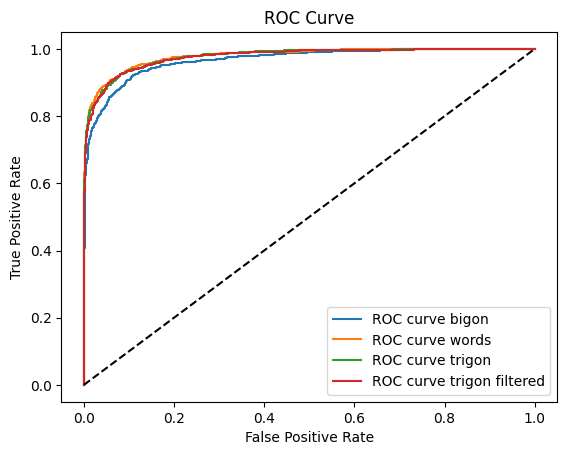

In [71]:
plt.plot(fpr_bigon, tpr_bigon, label="ROC curve bigon")
plt.plot(fpr_words, tpr_words, label="ROC curve words")
plt.plot(fpr_trigon, tpr_trigon, label="ROC curve trigon")
plt.plot(fpr_trigon_filtered, tpr_trigon_filtered, label="ROC curve trigon filtered")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

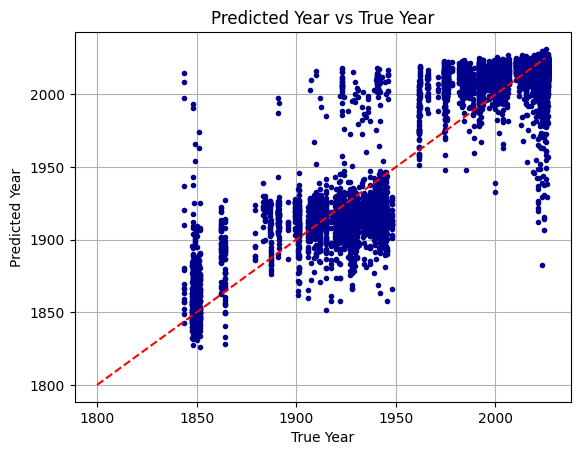

In [12]:
plt.plot(test_labels, model.predict(test_data), ".", color="darkblue")
plt.plot(val_labels, model.predict(val_data), ".", color="darkblue")
plt.xlabel("True Year")
plt.ylabel("Predicted Year")
plt.title("Predicted Year vs True Year")
plt.plot([1800, 2025], [1800, 2025], "r--")
plt.grid()

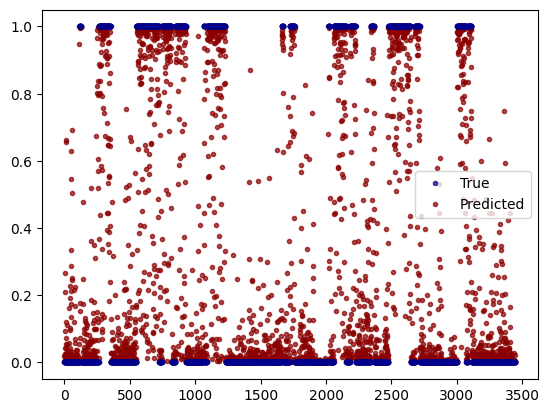

In [25]:
plt.plot(test_labels, '.', label="True", alpha=0.7, color="darkblue", zorder=3)
plt.plot(model.predict(test_data), '.', label="Predicted", alpha=0.7, color="darkred")
plt.legend()
plt.show()

In [16]:
idx = np.argsort(model.feature_importance(importance_type="gain"))[::-1]
print(np.array(bigons)[idx][:50])

['aa' 'å ' 'de' 'a ' 'øi' 'år' 'kj' 'ei' 'ee' 'qa' 'r ' 'ae' 'ej' 'gj'
 'e ' 'jø' 'kv' ' p' 'gø' 'ig' 'jo' 'ii' 'nd' 'lk' 's ' 'på' 'hr' 'do'
 'øj' ' h' 'ls' 'hi' 'i ' 'th' 'er' 'gu' ' d' 'hv' 'ju' ' a' 'ar' 'en'
 't ' 'in' 'vj' 'iø' 'et' 'el' 'rr' ' g']


In [ ]:
#np.savetxt("txt_files/words_ranked_years.txt", words[idx], delimiter="\n", fmt="%s")

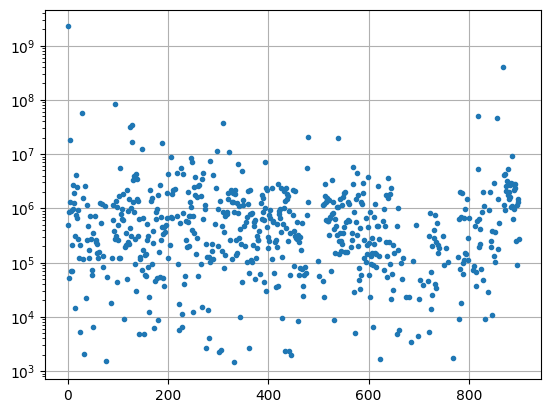

In [17]:
plt.plot(model.feature_importance(importance_type="gain"), ".")
plt.yscale("log")
plt.grid()

In [6]:
test_speech = open("test.txt", "r").read()
test_speech_data = bf.convert_to_data(test_speech, chars)

In [7]:
model.predict([test_speech_data])

array([23.64302537])

In [27]:
np.mean(labels)

np.float64(1993.833620919064)

In [13]:
model.predict(test_data)

array([ -43.45949295,  -55.31170448,  -41.86957323,  -61.60097825,
        -32.50387642,   15.8978201 ,   26.50305802,   10.3817101 ,
         23.54973952,  -75.1508267 ,   25.89405299,   24.26719992,
         19.27546165,   21.88278845,   18.91638827,   23.53752988,
         31.7233499 ,   15.75853587, -122.08753968,   23.71300754,
         18.44896129,   23.31839616,   16.0102125 ,   21.19210292,
          5.51567146,   21.60828215,   25.42972843,   25.01657786,
         26.29343679,   23.92454995,   26.18655454,   23.69506529,
         10.65264355,   24.38383314,   10.64566627,   23.69690549,
         23.34904098,   16.09072231,   22.8684581 ,   23.79729154,
         20.85383015,   24.04316806,   24.12764137,   23.89440954,
         16.31669968,   10.35891703,   20.33592943,   19.16334952,
         20.64140921,   24.11454124,   28.26948276,   25.23077268,
         26.1321853 ,   24.29464827,   17.40945138,   18.31327158,
          7.73357783,   16.13740252,   18.38265718,   15.15270

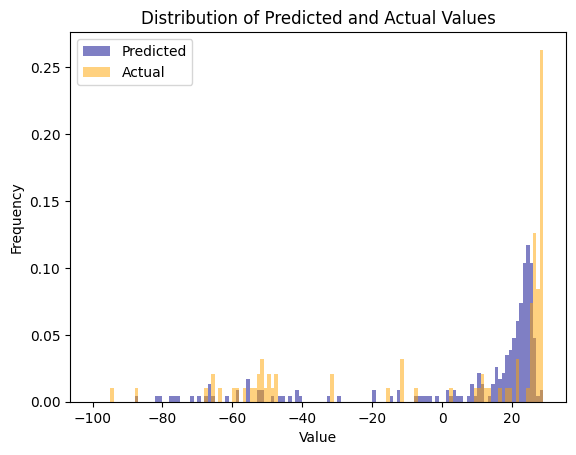

In [25]:
plt.hist(model.predict(test_data), bins=np.arange(-100, 30, 1), label="Predicted", color="darkblue", alpha=0.5, density=True)
plt.hist(test_labels, bins=np.arange(-100, 30, 1), label="Actual", color="orange", alpha=0.5, density=True)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted and Actual Values")
plt.legend()
plt.show()

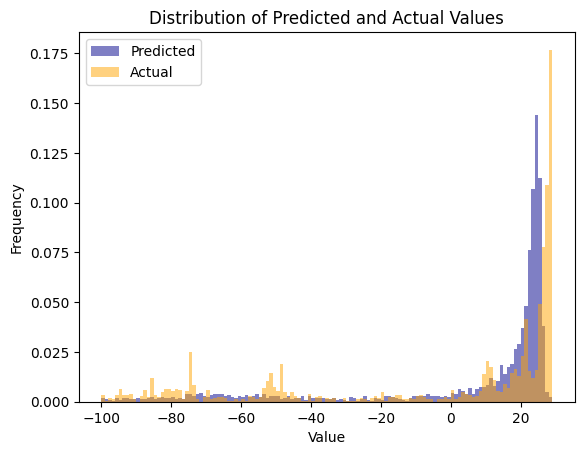

In [26]:
plt.hist(model.predict(train_data), bins=np.arange(-100, 30, 1), label="Predicted", color="darkblue", alpha=0.5, density=True)
plt.hist(train_labels, bins=np.arange(-100, 30, 1), label="Actual", color="orange", alpha=0.5, density=True)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted and Actual Values")
plt.legend()
plt.show()